In [78]:
import torch
import numpy as np
import pandas as pd
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from PIL import Image
import matplotlib.pyplot as plt

import tarfile
import io
import random

In [79]:
# Check if GPU is available
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

using device: cuda


In [80]:
# Helper functions to display images with an overlay of the mask
'''
Take a list of masks and scores associated with an image.
Display the masks on the image with their scores.
'''
def show_masks(image, masks, scores, borders=True):
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        show_mask(mask, plt.gca(), borders=borders)
        if len(scores) > 1:
            plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        elif len(scores) == 1:
            plt.title(f"Score: {score:.3f}", fontsize=18)
        plt.axis('off')
        plt.show()

'''
Take a mask and display it on a given axis.
Used to overlay a mask on its corresponding image
'''
def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([255/255, 30/255, 60/255, 0.3])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2)
    ax.imshow(mask_image)

In [81]:
'''
Takes an image and a predictor.
Predicts masks for the image and returns the masks with
scores and logits associated with the predicted mask.
'''
def predictMask(img, predictor, input_point = np.empty((0, 2)), input_label = np.empty((0,), dtype=int)):    
    predictor.set_image(img)
    pred_masks, scores, logits = predictor.predict(
        point_coords = input_point,
        point_labels = input_label,
        multimask_output = False
     )
    return pred_masks, scores, logits

In [82]:
# Define the pretrained model configuration and dataset you want to use
modelPath = "./sam2_river_masking.pt"
metaDataPath = "./mask_meta.csv"
metaData = pd.read_csv(metaDataPath)
# Filter out the training data
metaData = metaData[metaData['rapid_split'] != 'train']

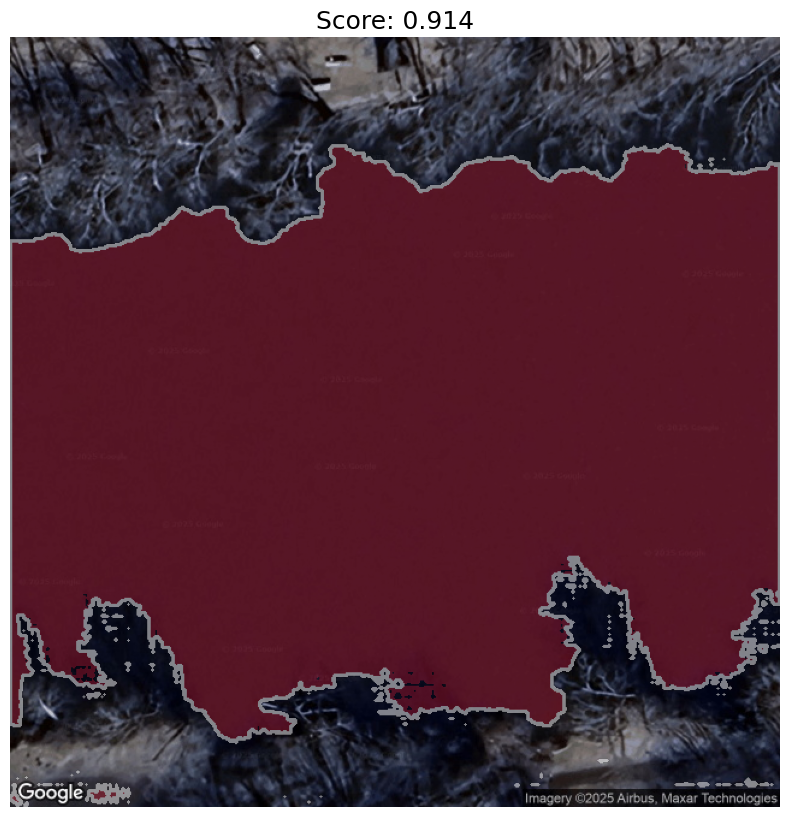

In [83]:
# Load in the SAM2 model
sam2_checkpoint = "../checkpoints/sam2.1_hiera_tiny.pt"
model_cfg = "./configs/sam2.1/sam2.1_hiera_t.yaml"

sam2_model = build_sam2(model_cfg, sam2_checkpoint, device=device)

predictor = SAM2ImagePredictor(sam2_model)
# Load the model state that we trained
predictor.model.load_state_dict(torch.load(modelPath))

tar_path = "./mask_dataset.tar"
# Load an image from the dataset and predict a mask
key = metaData["image"].iloc[3]
key_img = key + ".jpg"
key_mask = key + ".npy"
with tarfile.open(tar_path, "r") as tar:
    member_dict = {m.name: m for m in tar.getmembers()}
    member = member_dict[key_img]
    file = tar.extractfile(member)
    image = Image.open(file).convert("RGB")

pred_masks, scores, logits = predictMask(image, predictor)
show_masks(image, pred_masks, scores, borders=True)

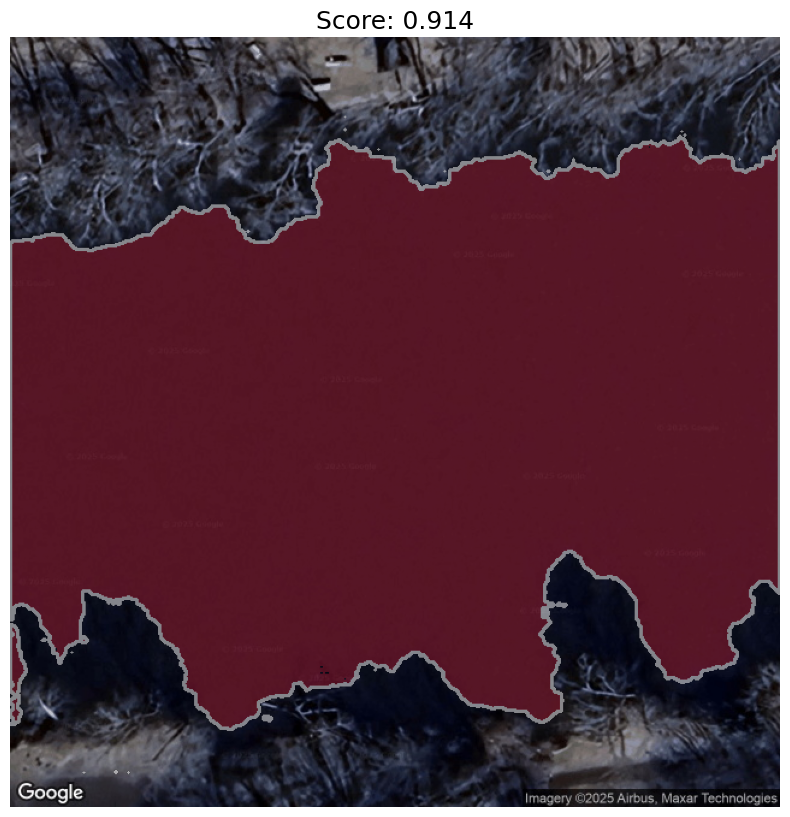

In [84]:
# Display the ground truth mask for the same image
with tarfile.open(tar_path, "r") as tar:
    member_dict = {m.name: m for m in tar.getmembers()}
    member = member_dict[key_img]
    file = tar.extractfile(member)
    image = Image.open(file).convert("RGB")
    mask_member = member_dict[key_mask]
    mask_file = tar.extractfile(mask_member)
    mask_content = mask_file.read()
    mask = np.load(io.BytesIO(mask_content))
    mask = np.unpackbits(mask, axis=-1)

pred_masks, scores, logits = predictMask(image, predictor)
mask = mask.reshape(1, mask.shape[0], mask.shape[1])
show_masks(image, mask, scores, borders=True)

In [85]:
'''
Calculate the Intersection over Union (IoU) score between the predicted mask and the ground truth mask.
'''
def iou_score(mask_true, mask_pred):
    # Ensure binary masks (0 or 1)
    mask_true = mask_true.astype(bool)
    mask_pred = mask_pred > 0.5
    
    intersection = np.logical_and(mask_true, mask_pred).sum()
    union = np.logical_or(mask_true, mask_pred).sum()

    if mask_true.astype(float).sum() == 0:
        loss = mask_pred.astype(float).sum() / (mask_pred.shape[0] * mask_pred.shape[1] * mask_pred.shape[2])
        return loss
    
    if union == 0:
        return 1.0  # Both empty — define IoU as perfect match
    else:
        return intersection / union
    

iou = iou_score(mask, pred_masks)
print(f"IoU score: {iou:.4f}")


IoU score: 0.9517


In [86]:
# Create new columns in metaData to hold the predicted mask scores and the IoU scores
metaData['mask_score'] = 0.0
metaData['iou_score'] = 0.0

In [87]:
# Create a list to hold IoU scores for each image
ious = []

# Iterate through the metadata, extract images and masks, and predict masks
for i in range(metaData.shape[0]):
    key = metaData["image"].iloc[i]
    key_img = key + ".jpg"
    key_mask = key + ".npy"
    with tarfile.open(tar_path, "r") as tar:
        member_dict = {m.name: m for m in tar.getmembers()}
        member = member_dict[key_img]
        file = tar.extractfile(member)
        image = Image.open(file).convert("RGB")
        mask_member = member_dict[key_mask]
        mask_file = tar.extractfile(mask_member)
        mask_content = mask_file.read()
        mask = np.load(io.BytesIO(mask_content))
        mask = np.unpackbits(mask, axis=-1)

    pred_masks, scores, logits = predictMask(image, predictor)
    mask = mask.reshape(1, mask.shape[0], mask.shape[1])
    iou = iou_score(mask, pred_masks)
    ious.append(iou)
    # Add the predicted mask score and IoU score to the metadata
    metaData.loc[metaData['image'] == key, 'mask_score'] = scores[0]
    metaData.loc[metaData['image'] == key, 'iou_score'] = iou

# Select only the relevant columns for the cleaned metadata
metaDataClean = metaData[['image', 'mask_score', 'iou_score', 'rapid_split']]
print(metaDataClean.head())
metaDataClean.to_csv("mask_scores.csv", index=False)

                                image  mask_score  iou_score rapid_split
0  h010300_-69~7538055_44~6854904_z19    0.386719   0.036916         val
1  h010500_-67~3891662_44~7384418_z19    0.367188   0.281517         val
2  h010500_-67~9941013_44~5866337_z19    0.285156   0.004179         val
3  h010600_-70~4973221_43~4982171_z19    0.914062   0.951669         val
4    h010600_-70~71347_43~4098167_z19    0.808594   0.961252         val


In [91]:
# Calculate the average IoU score for different mask score thresholds for the validation and test sets together
rows = []

metaDataCleanVal = metaDataClean[metaDataClean['rapid_split'] == 'val']

test_score = 0
while test_score < 1:
    test_data = metaDataCleanVal[metaDataCleanVal['mask_score'] >= test_score]
    if not test_data.empty:
        count = test_data.shape[0]
        percent = count / metaDataClean.shape[0]
        avg_iou = test_data['iou_score'].mean()
        rows.append((test_score, avg_iou, count, percent))
    test_score += 0.05

avg_ious = pd.DataFrame(rows, columns=['min_mask_score', 'avg_iou', 'counts', 'percent'])
print(avg_ious)

    min_mask_score   avg_iou  counts   percent
0             0.00  0.429896     138  0.418182
1             0.05  0.429896     138  0.418182
2             0.10  0.429896     138  0.418182
3             0.15  0.426332     137  0.415152
4             0.20  0.426332     137  0.415152
5             0.25  0.427712     133  0.403030
6             0.30  0.441507     127  0.384848
7             0.35  0.458387     118  0.357576
8             0.40  0.482888     107  0.324242
9             0.45  0.505146      95  0.287879
10            0.50  0.499323      81  0.245455
11            0.55  0.520410      66  0.200000
12            0.60  0.532201      53  0.160606
13            0.65  0.568792      45  0.136364
14            0.70  0.559182      41  0.124242
15            0.75  0.591646      31  0.093939
16            0.80  0.668524      27  0.081818
17            0.85  0.859585      14  0.042424
18            0.90  0.885101      10  0.030303
19            0.95  0.986307       3  0.009091


In [89]:
# Repeat the process for only the test set
rows = []

metaDataCleanTest = metaDataClean[metaDataClean['rapid_split'] == 'test']

test_score = 0
while test_score < 1:
    test_data = metaDataCleanTest[metaDataCleanTest['mask_score'] >= test_score]
    if not test_data.empty:
        count = test_data.shape[0]
        percent = count / metaDataCleanTest.shape[0]
        avg_iou = test_data['iou_score'].mean()
        rows.append((test_score, avg_iou, count, percent))
    test_score += 0.05

avg_ious = pd.DataFrame(rows, columns=['min_mask_score', 'avg_iou', 'counts', 'percent'])
print(avg_ious)

    min_mask_score   avg_iou  counts   percent
0             0.00  0.567722     192  1.000000
1             0.05  0.567722     192  1.000000
2             0.10  0.567722     192  1.000000
3             0.15  0.567722     192  1.000000
4             0.20  0.567722     192  1.000000
5             0.25  0.570139     191  0.994792
6             0.30  0.569995     185  0.963542
7             0.35  0.580983     176  0.916667
8             0.40  0.585586     169  0.880208
9             0.45  0.599979     151  0.786458
10            0.50  0.620746     144  0.750000
11            0.55  0.634395     138  0.718750
12            0.60  0.662107     121  0.630208
13            0.65  0.702116     104  0.541667
14            0.70  0.724274      97  0.505208
15            0.75  0.736388      78  0.406250
16            0.80  0.774428      61  0.317708
17            0.85  0.831750      44  0.229167
18            0.90  0.894915      23  0.119792
19            0.95  0.986426       5  0.026042


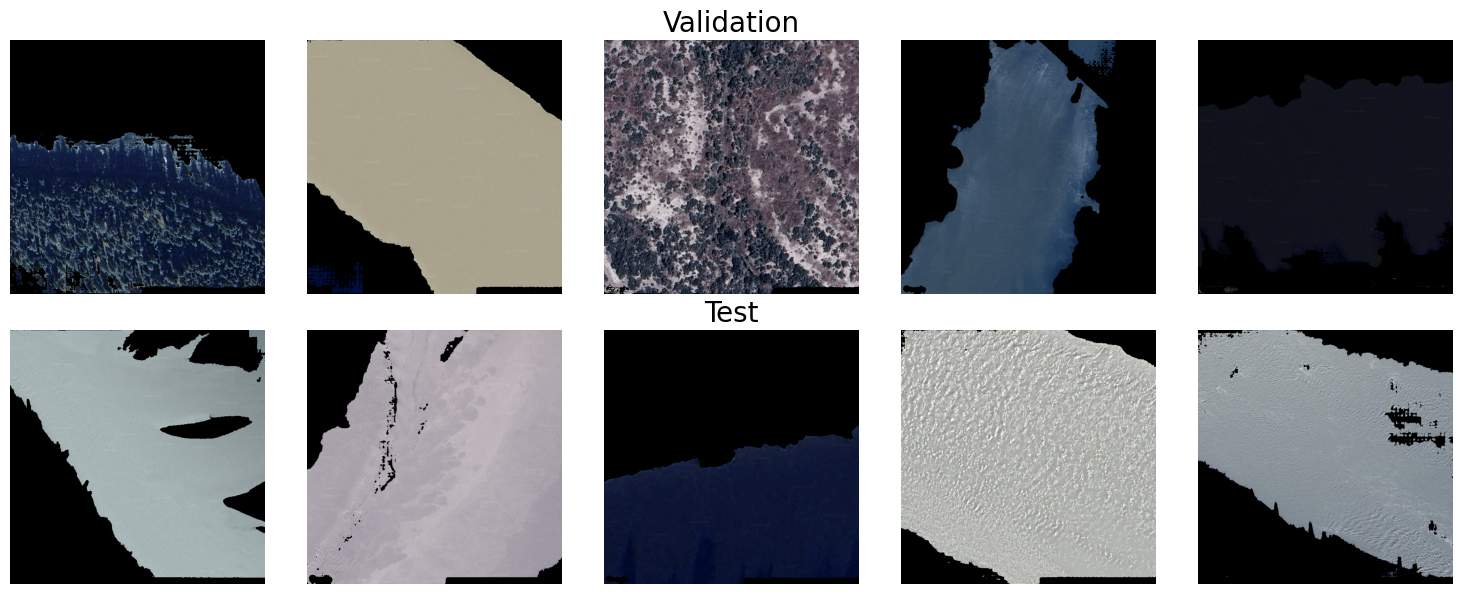

In [ ]:
# Plot some images who have a mask score of 0.9 or higher
high_score_val = metaDataCleanVal[metaDataCleanVal['mask_score'] >= 0.9]

# Randomly select 5 images from high_score_val
img_indices_val = random.sample(range(high_score_val.shape[0]), 5)

images_val = []
images_test = []

for i in img_indices_val:
    key = high_score_val["image"].iloc[i]
    key_img = key + ".jpg"
    key_mask = key + ".npy"
    with tarfile.open(tar_path, "r") as tar:
        member_dict = {m.name: m for m in tar.getmembers()}
        member = member_dict[key_img]
        file = tar.extractfile(member)
        image = Image.open(file).convert("RGB")
        image_array = np.array(image)

    pred_masks, scores, logits = predictMask(image, predictor)
    mask = np.squeeze(pred_masks)
    mask_expanded = mask[:, :, np.newaxis]
    masked_array = image_array * mask_expanded
    masked_image = masked_array.astype(np.uint8)
    images_val.append(masked_image)

high_score_test = metaDataCleanTest[metaDataCleanTest['mask_score'] >= 0.9]

# Randomly select 5 images from high_score_test
img_indices_test = random.sample(range(high_score_test.shape[0]), 5)
for i in img_indices_test:
    key = high_score_test["image"].iloc[i]
    key_img = key + ".jpg"
    key_mask = key + ".npy"
    with tarfile.open(tar_path, "r") as tar:
        member_dict = {m.name: m for m in tar.getmembers()}
        member = member_dict[key_img]
        file = tar.extractfile(member)
        image = Image.open(file).convert("RGB")
        image_array = np.array(image)

    pred_masks, scores, logits = predictMask(image, predictor)
    mask = np.squeeze(pred_masks)
    mask_expanded = mask[:, :, np.newaxis]
    masked_array = image_array * mask_expanded
    masked_image = masked_array.astype(np.uint8)
    images_test.append(masked_image)

# Plot the masked images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Row 1 → Validation
for idx, ax in enumerate(axes[0]):
    if idx < len(images_val):
        ax.imshow(images_val[idx])
    ax.axis('off')
    if idx == 2:
        ax.set_title("Validation", fontsize=20, loc='center')

# Row 2 → Test
for idx, ax in enumerate(axes[1]):
    if idx < len(images_test):
        ax.imshow(images_test[idx])
    ax.axis('off')
    if idx == 2:
        ax.set_title("Test", fontsize=20, loc='center')

plt.tight_layout()
plt.show()
